# Ejercicio 3: Heurísticas y Pesos

Comparación de los algoritmos A* y Dijkstra sobre una cuadrícula con obstáculos dispersos.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import heapq
import time

## 1. Creación del escenario (con obstáculos dispersos)

In [12]:
filas, columnas = 30, 30
np.random.seed(42)

mapa = np.zeros((filas, columnas), dtype=int)

#colocar obstaculos dispersos
for f in range(filas):
    for c in range(columnas):
        if np.random.random() < 0.2:
            mapa[f][c] = 1

inicio = (2, 2)
fin = (27, 27)

#asegurar que inicio/fin estan libres
mapa[inicio[0]][inicio[1]] = 0
mapa[fin[0]][fin[1]] = 0

#limpiar alrededores de inicio/fin
for df in [-1, 0, 1]:
    for dc in [-1, 0, 1]:
        nf, nc = inicio[0]+df, inicio[1]+dc
        if 0 <= nf < filas and 0 <= nc < columnas:
            mapa[nf][nc] = 0
        nf, nc = fin[0]+df, fin[1]+dc
        if 0 <= nf < filas and 0 <= nc < columnas:
            mapa[nf][nc] = 0

print(f"Mapa de {filas}x{columnas}")
print(f"Inicio: {inicio}")
print(f"Fin: {fin}")
print(f"Obstáculos: {np.sum(mapa)} celdas")

Mapa de 30x30
Inicio: (2, 2)
Fin: (27, 27)
Obstáculos: 201 celdas


## 2. Implementación de los algoritmos

In [13]:
def obtenerVecinos(nodo, mapa):
    #vecinos en 4 direcciones
    filas, columnas = mapa.shape
    direcciones = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    vecinos = []
    for df, dc in direcciones:
        nf, nc = nodo[0] + df, nodo[1] + dc
        if 0 <= nf < filas and 0 <= nc < columnas and mapa[nf][nc] == 0:
            vecinos.append((nf, nc))
    return vecinos

def heuristicaManhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def ejecutarAEstrella(mapa, inicio, fin):
    #a* con heuristica manhattan
    tiempoInicio = time.perf_counter()
    
    frontera = []
    heapq.heappush(frontera, (0, inicio))
    costoAcumulado = {inicio: 0}
    padres = {inicio: None}
    explorados = set()
    ordenExploracion = []
    pasos = 0
    
    while frontera:
        pasos += 1
        _, actual = heapq.heappop(frontera)
        
        if actual in explorados:
            continue
        
        explorados.add(actual)
        ordenExploracion.append(actual)
        
        if actual == fin:
            break
        
        for vecino in obtenerVecinos(actual, mapa):
            nuevoCosto = costoAcumulado[actual] + 1
            if vecino not in costoAcumulado or nuevoCosto < costoAcumulado[vecino]:
                costoAcumulado[vecino] = nuevoCosto
                prioridad = nuevoCosto + heuristicaManhattan(vecino, fin)
                heapq.heappush(frontera, (prioridad, vecino))
                padres[vecino] = actual
    
    tiempoFin = time.perf_counter()
    
    #reconstruir camino
    camino = []
    nodo = fin
    while nodo is not None:
        camino.append(nodo)
        nodo = padres.get(nodo)
    camino.reverse()
    
    #nodos en frontera al final
    nodosFrontera = len([n for _, n in frontera if n not in explorados])
    
    return {
        'nombre': 'A*',
        'explorados': explorados,
        'ordenExploracion': ordenExploracion,
        'camino': camino,
        'numExplorados': len(explorados),
        'numFrontera': nodosFrontera,
        'pasos': pasos,
        'tiempo': tiempoFin - tiempoInicio,
        'distancia': len(camino) - 1
    }

def ejecutarDijkstra(mapa, inicio, fin):
    #dijkstra / ucs
    tiempoInicio = time.perf_counter()
    
    frontera = []
    heapq.heappush(frontera, (0, inicio))
    costoAcumulado = {inicio: 0}
    padres = {inicio: None}
    explorados = set()
    ordenExploracion = []
    pasos = 0
    
    while frontera:
        pasos += 1
        _, actual = heapq.heappop(frontera)
        
        if actual in explorados:
            continue
        
        explorados.add(actual)
        ordenExploracion.append(actual)
        
        if actual == fin:
            break
        
        for vecino in obtenerVecinos(actual, mapa):
            nuevoCosto = costoAcumulado[actual] + 1
            if vecino not in costoAcumulado or nuevoCosto < costoAcumulado[vecino]:
                costoAcumulado[vecino] = nuevoCosto
                heapq.heappush(frontera, (nuevoCosto, vecino))
                padres[vecino] = actual
    
    tiempoFin = time.perf_counter()
    
    #reconstruir camino
    camino = []
    nodo = fin
    while nodo is not None:
        camino.append(nodo)
        nodo = padres.get(nodo)
    camino.reverse()
    
    nodosFrontera = len([n for _, n in frontera if n not in explorados])
    
    return {
        'nombre': 'Dijkstra (UCS)',
        'explorados': explorados,
        'ordenExploracion': ordenExploracion,
        'camino': camino,
        'numExplorados': len(explorados),
        'numFrontera': nodosFrontera,
        'pasos': pasos,
        'tiempo': tiempoFin - tiempoInicio,
        'distancia': len(camino) - 1
    }

print("Algoritmos definidos correctamente.")

Algoritmos definidos correctamente.


## 3. Ejecución de A* y Dijkstra

In [14]:
resultadoAEstrella = ejecutarAEstrella(mapa, inicio, fin)
resultadoDijkstra = ejecutarDijkstra(mapa, inicio, fin)

print(f"A* - Nodos explorados: {resultadoAEstrella['numExplorados']}")
print(f"Dijkstra - Nodos explorados: {resultadoDijkstra['numExplorados']}")

A* - Nodos explorados: 323
Dijkstra - Nodos explorados: 681


## 4. Visualización comparativa de nodos explorados

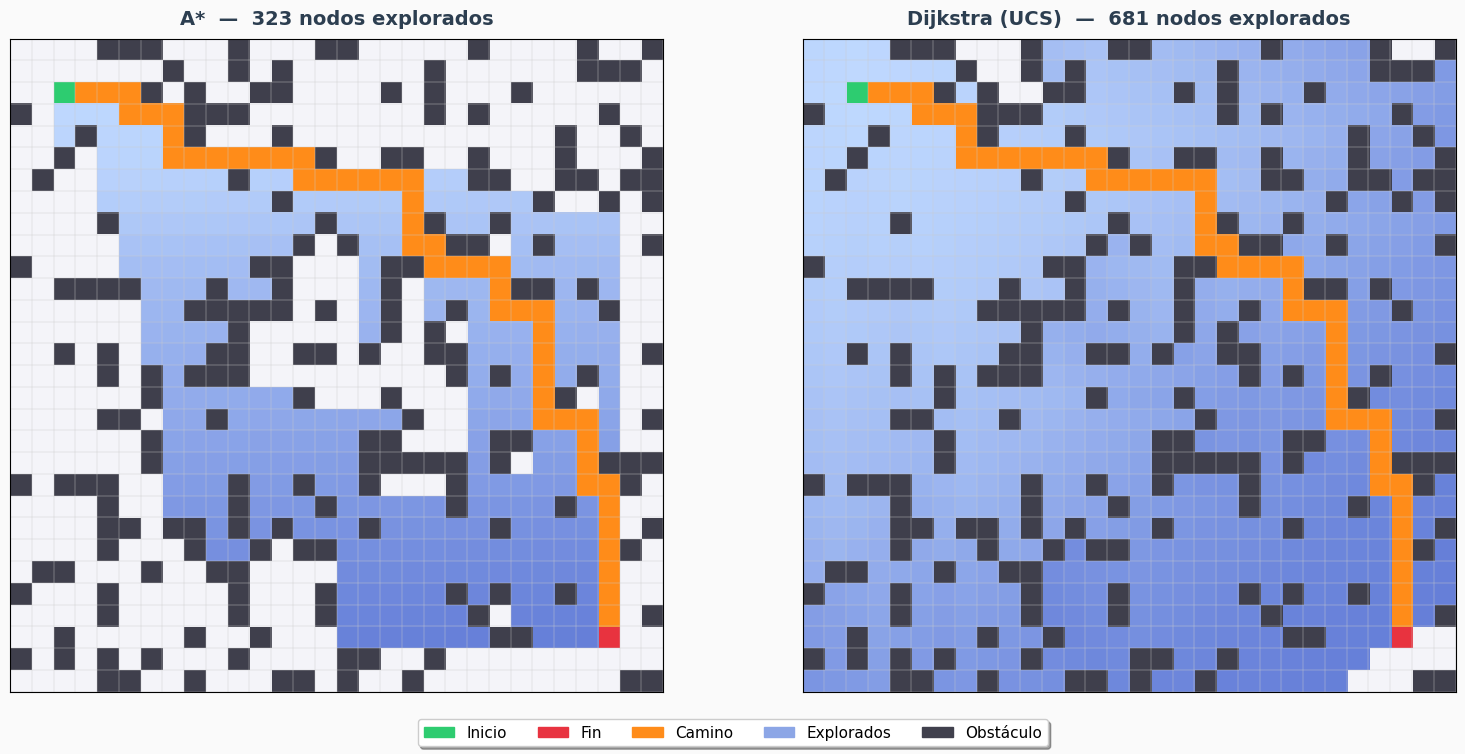


Imagen 1. Comparación de nodos explorados por A* y Dijkstra sobre el mismo mapa


In [15]:
def dibujarMapa(ax, mapa, resultado, titulo):
    filas, columnas = mapa.shape
    
    imagen = np.ones((filas, columnas, 3))
    
    imagen[:, :] = [0.96, 0.96, 0.98]
    
    for f in range(filas):
        for c in range(columnas):
            if mapa[f][c] == 1:
                imagen[f][c] = [0.25, 0.25, 0.30]
    
    totalExplorados = len(resultado['ordenExploracion'])
    for i, (f, c) in enumerate(resultado['ordenExploracion']):
        t = i / max(totalExplorados - 1, 1)
        r = 0.75 - 0.35 * t
        g = 0.85 - 0.35 * t
        b = 1.0 - 0.15 * t
        imagen[f][c] = [r, g, b]
    
    for f, c in resultado['camino']:
        imagen[f][c] = [1.0, 0.55, 0.10]
    
    imagen[inicio[0]][inicio[1]] = [0.18, 0.80, 0.44]
    imagen[fin[0]][fin[1]] = [0.91, 0.20, 0.25]
    
    ax.imshow(imagen, interpolation='nearest')
    
    ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linewidth=0.3)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10, color='#2c3e50')

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#fafafa')

dibujarMapa(ejes[0], mapa, resultadoAEstrella, f"A*  —  {resultadoAEstrella['numExplorados']} nodos explorados")
dibujarMapa(ejes[1], mapa, resultadoDijkstra, f"Dijkstra (UCS)  —  {resultadoDijkstra['numExplorados']} nodos explorados")

leyendas = [
    mpatches.Patch(color=[0.18, 0.80, 0.44], label='Inicio'),
    mpatches.Patch(color=[0.91, 0.20, 0.25], label='Fin'),
    mpatches.Patch(color=[1.0, 0.55, 0.10], label='Camino'),
    mpatches.Patch(color=[0.55, 0.65, 0.90], label='Explorados'),
    mpatches.Patch(color=[0.25, 0.25, 0.30], label='Obstáculo'),
]
fig.legend(handles=leyendas, loc='lower center', ncol=5, fontsize=11,
           frameon=True, fancybox=True, shadow=True, edgecolor='#cccccc')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('comparacion_exploracion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 1. Comparación de nodos explorados por A* y Dijkstra sobre el mismo mapa")

## 5. Visualización individual de cada algoritmo

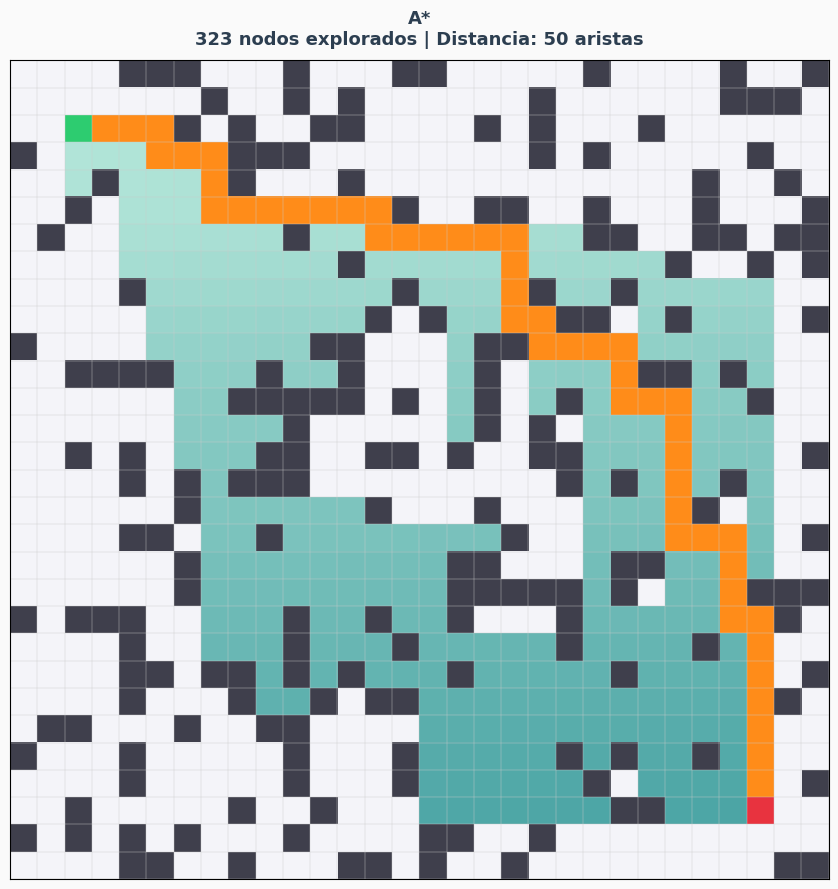


Imagen 2. Resultado detallado de A* — nodos explorados y camino encontrado.


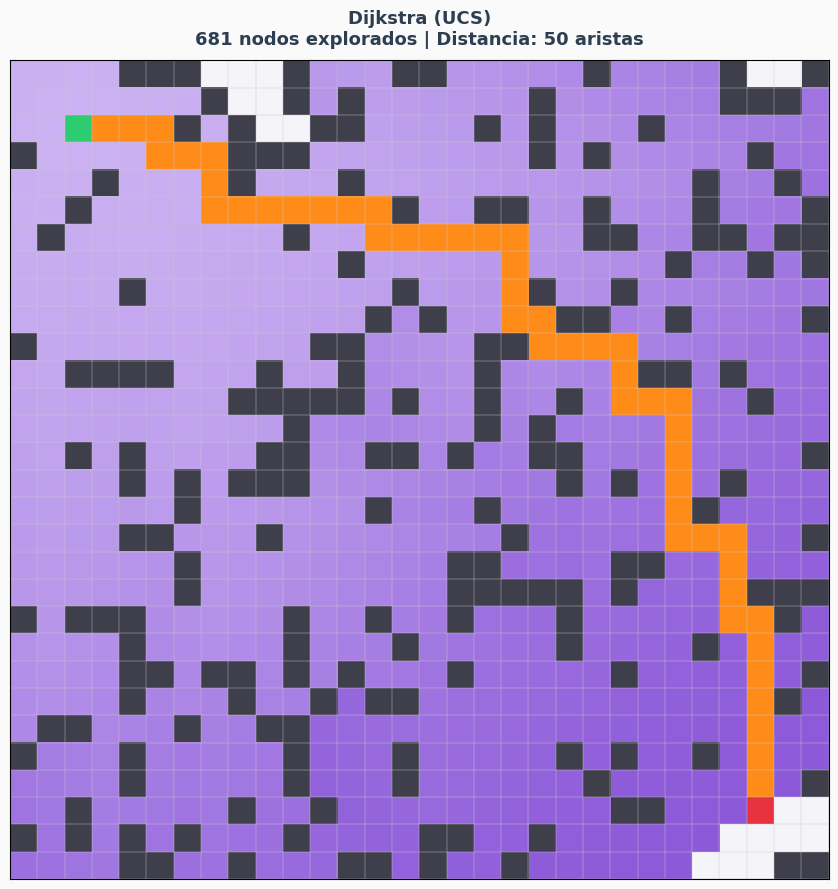


Imagen 3. Resultado detallado de Dijkstra (UCS) — nodos explorados y camino encontrado.


In [16]:
def dibujarDetallado(mapa, resultado, nombreArchivo, etiqueta):
    filas, columnas = mapa.shape
    fig, ax = plt.subplots(figsize=(9, 9))
    fig.patch.set_facecolor('#fafafa')
    
    imagen = np.ones((filas, columnas, 3))
    imagen[:, :] = [0.96, 0.96, 0.98]
    
    for f in range(filas):
        for c in range(columnas):
            if mapa[f][c] == 1:
                imagen[f][c] = [0.25, 0.25, 0.30]
    
    totalExplorados = len(resultado['ordenExploracion'])
    esAEstrella = resultado['nombre'] == 'A*'
    
    for i, (f, c) in enumerate(resultado['ordenExploracion']):
        t = i / max(totalExplorados - 1, 1)
        if esAEstrella:
            #tonos verdes-azulados
            r = 0.70 - 0.40 * t
            g = 0.90 - 0.25 * t
            b = 0.85 - 0.20 * t
        else:
            #tonos morados
            r = 0.80 - 0.25 * t
            g = 0.70 - 0.35 * t
            b = 0.95 - 0.10 * t
        imagen[f][c] = [r, g, b]
    
    for f, c in resultado['camino']:
        imagen[f][c] = [1.0, 0.55, 0.10]
    
    imagen[inicio[0]][inicio[1]] = [0.18, 0.80, 0.44]
    imagen[fin[0]][fin[1]] = [0.91, 0.20, 0.25]
    
    ax.imshow(imagen, interpolation='nearest')
    ax.set_xticks(np.arange(-0.5, columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, filas, 1), minor=True)
    ax.grid(which='minor', color='#cccccc', linewidth=0.3)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.set_title(f"{resultado['nombre']}\n{resultado['numExplorados']} nodos explorados | Distancia: {resultado['distancia']} aristas",
                 fontsize=13, fontweight='bold', color='#2c3e50', pad=12)
    
    plt.tight_layout()
    plt.savefig(nombreArchivo, dpi=150, bbox_inches='tight', facecolor='#fafafa')
    plt.show()
    print(f"\n{etiqueta}")

dibujarDetallado(mapa, resultadoAEstrella, 'aestrella_detalle.png',
                 'Imagen 2. Resultado detallado de A* — nodos explorados y camino encontrado.')

dibujarDetallado(mapa, resultadoDijkstra, 'dijkstra_detalle.png',
                 'Imagen 3. Resultado detallado de Dijkstra (UCS) — nodos explorados y camino encontrado.')

## 6. Tabla comparativa

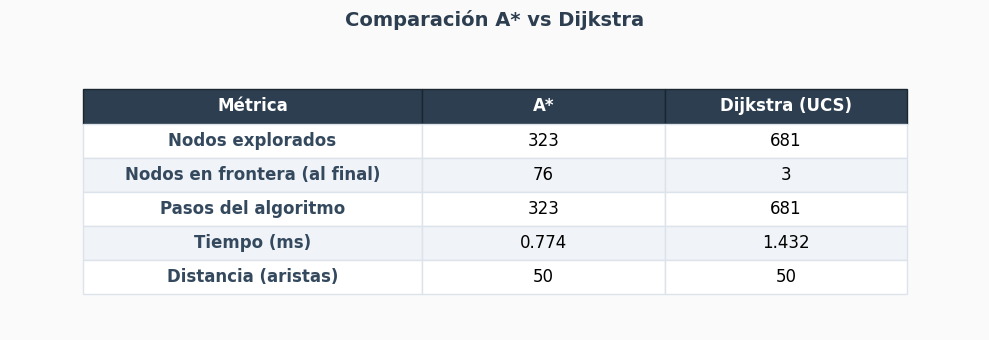


Tabla 1. Comparación de métricas entre A* y Dijkstra (UCS).


In [17]:
datosTabla = [
    ['Métrica', 'A*', 'Dijkstra (UCS)'],
    ['Nodos explorados', str(resultadoAEstrella['numExplorados']), str(resultadoDijkstra['numExplorados'])],
    ['Nodos en frontera (al final)', str(resultadoAEstrella['numFrontera']), str(resultadoDijkstra['numFrontera'])],
    ['Pasos del algoritmo', str(resultadoAEstrella['pasos']), str(resultadoDijkstra['pasos'])],
    ['Tiempo (ms)', f"{resultadoAEstrella['tiempo']*1000:.3f}", f"{resultadoDijkstra['tiempo']*1000:.3f}"],
    ['Distancia (aristas)', str(resultadoAEstrella['distancia']), str(resultadoDijkstra['distancia'])],
]

fig, ax = plt.subplots(figsize=(10, 3.5))
fig.patch.set_facecolor('#fafafa')
ax.axis('off')

coloresEncabezado = ['#2c3e50'] * 3
coloresCelda = [['#f7f9fc', '#e8f4f8', '#f0e8f8']] * (len(datosTabla) - 1)

tabla = ax.table(
    cellText=datosTabla,
    cellLoc='center',
    loc='center',
    colWidths=[0.35, 0.25, 0.25]
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1, 2.0)

#estilo del encabezado
for j in range(3):
    celda = tabla[0, j]
    celda.set_facecolor('#2c3e50')
    celda.set_text_props(color='white', fontweight='bold')
    celda.set_edgecolor('#1a252f')

#estilo de filas
for i in range(1, len(datosTabla)):
    colorFondo = '#f0f4f8' if i % 2 == 0 else '#ffffff'
    for j in range(3):
        celda = tabla[i, j]
        celda.set_facecolor(colorFondo)
        celda.set_edgecolor('#dde3ea')
        if j == 0:
            celda.set_text_props(fontweight='bold', color='#34495e')

plt.title('Comparación A* vs Dijkstra', fontsize=14, fontweight='bold',
          color='#2c3e50', pad=20)
plt.tight_layout()
plt.savefig('tabla_comparativa.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nTabla 1. Comparación de métricas entre A* y Dijkstra (UCS).")

## 7. Gráfico de barras comparativo

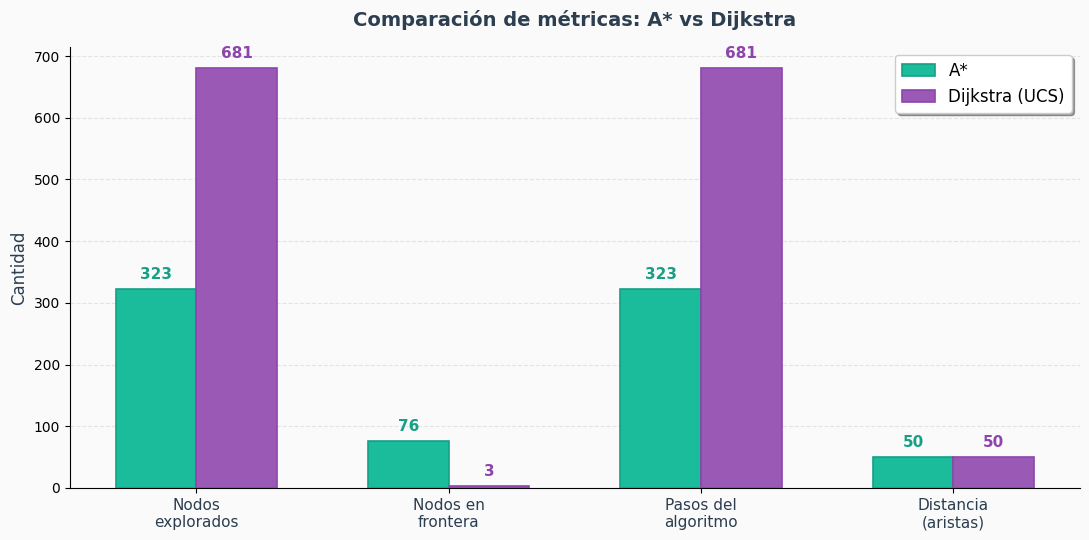


Imagen 4. Gráfico de barras comparando las métricas principales de ambos algoritmos.


In [18]:
metricas = ['Nodos\nexplorados', 'Nodos en\nfrontera', 'Pasos del\nalgoritmo', 'Distancia\n(aristas)']
valoresAEstrella = [resultadoAEstrella['numExplorados'], resultadoAEstrella['numFrontera'],
                    resultadoAEstrella['pasos'], resultadoAEstrella['distancia']]
valoresDijkstra = [resultadoDijkstra['numExplorados'], resultadoDijkstra['numFrontera'],
                   resultadoDijkstra['pasos'], resultadoDijkstra['distancia']]

x = np.arange(len(metricas))
ancho = 0.32

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

barrasA = ax.bar(x - ancho/2, valoresAEstrella, ancho, label='A*',
                  color='#1abc9c', edgecolor='#16a085', linewidth=1.2, zorder=3)
barrasD = ax.bar(x + ancho/2, valoresDijkstra, ancho, label='Dijkstra (UCS)',
                  color='#9b59b6', edgecolor='#8e44ad', linewidth=1.2, zorder=3)

#valores sobre las barras
for barra in barrasA:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}', xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#16a085')

for barra in barrasD:
    alto = barra.get_height()
    ax.annotate(f'{int(alto)}', xy=(barra.get_x() + barra.get_width() / 2, alto),
                xytext=(0, 5), textcoords='offset points', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#8e44ad')

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11, color='#2c3e50')
ax.set_ylabel('Cantidad', fontsize=12, color='#2c3e50')
ax.set_title('Comparación de métricas: A* vs Dijkstra', fontsize=14,
             fontweight='bold', color='#2c3e50', pad=15)
ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, edgecolor='#cccccc')
ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barras_comparativas.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print("\nImagen 4. Gráfico de barras comparando las métricas principales de ambos algoritmos.")

## 8. Preguntas

### Pregunta 1: ¿Se puede alterar el mapa para que A* termine significativamente más rápido que Dijkstra?

Sí se puede alterar, y realmente es bastante sencillo de hacerlo. La clave está en que A* usa una heuristica (tipo, en este caso la distancia/longitud Manhattan) para "apuntar" hacia la meta. Ahora, del otro lado Dijkstra expande en todas las direcciones sin tal preferencia

Si se quisiera lograr que la diferencia sea más grande, se puede poner el inicio y el fin lejos pero con un camino relativamente directo entre ellos. También usar un mapa grande y abierto (pocos obstáculos) y/o crear un pasillo o corredor que conecte inicio y fin

Ejemplo con mapa abierto:

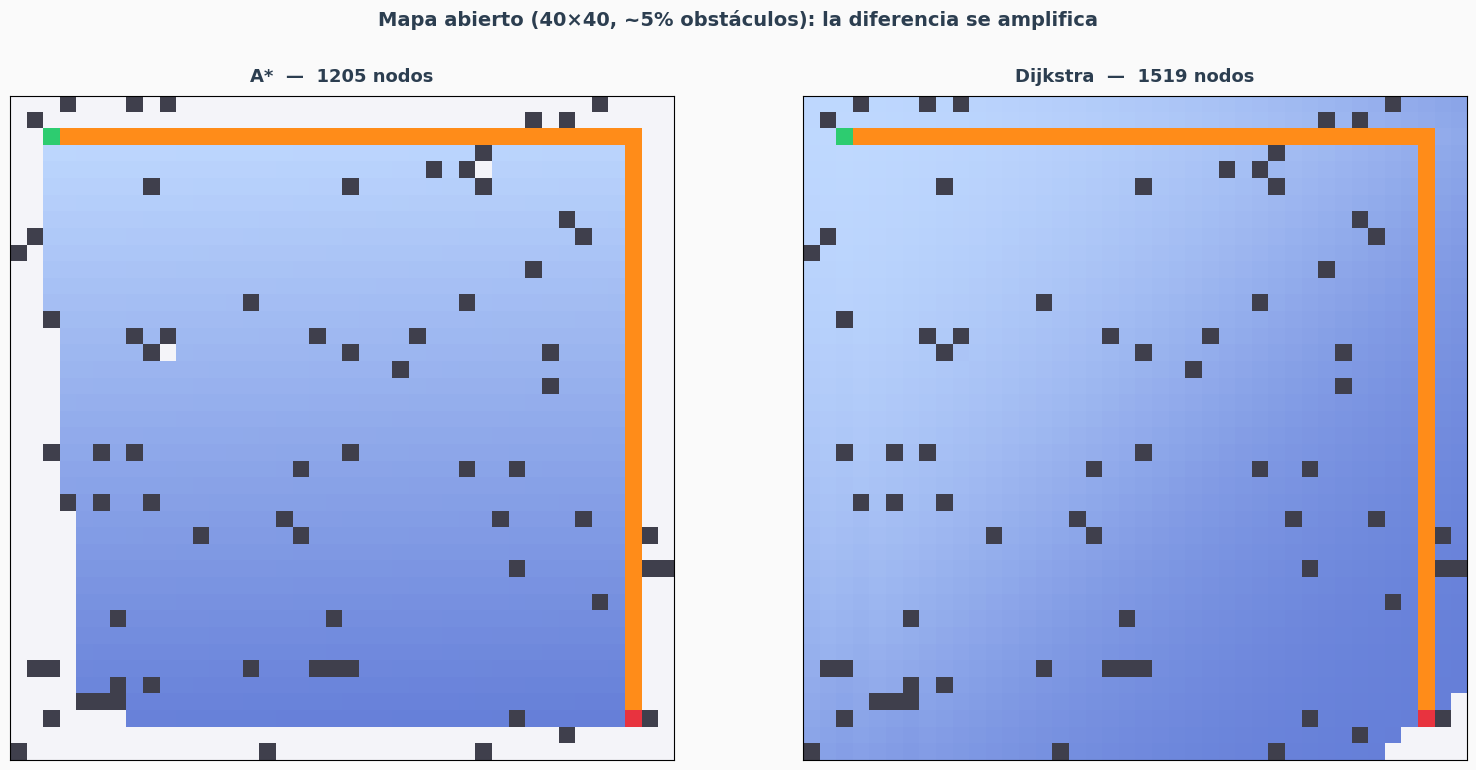


Imagen 5. Mapa abierto — A* explora 1205 nodos vs 1519 de Dijkstra.
Reducción: A* exploró 20.7% menos nodos.


In [19]:
mapaAbierto = np.zeros((40, 40), dtype=int)
np.random.seed(99)

for f in range(40):
    for c in range(40):
        if np.random.random() < 0.05:
            mapaAbierto[f][c] = 1

inicioAbierto = (2, 2)
finAbierto = (37, 37)
mapaAbierto[inicioAbierto[0]][inicioAbierto[1]] = 0
mapaAbierto[finAbierto[0]][finAbierto[1]] = 0

resAbierto = ejecutarAEstrella(mapaAbierto, inicioAbierto, finAbierto)
resDijkAbierto = ejecutarDijkstra(mapaAbierto, inicioAbierto, finAbierto)

fig, ejes = plt.subplots(1, 2, figsize=(16, 7.5))
fig.patch.set_facecolor('#fafafa')

def dibujarMapaGenerico(ax, mp, res, ini, fn, titulo):
    filas, columnas = mp.shape
    imagen = np.ones((filas, columnas, 3))
    imagen[:, :] = [0.96, 0.96, 0.98]
    for f in range(filas):
        for c in range(columnas):
            if mp[f][c] == 1:
                imagen[f][c] = [0.25, 0.25, 0.30]
    total = len(res['ordenExploracion'])
    for i, (f, c) in enumerate(res['ordenExploracion']):
        t = i / max(total - 1, 1)
        imagen[f][c] = [0.75 - 0.35*t, 0.85 - 0.35*t, 1.0 - 0.15*t]
    for f, c in res['camino']:
        imagen[f][c] = [1.0, 0.55, 0.10]
    imagen[ini[0]][ini[1]] = [0.18, 0.80, 0.44]
    imagen[fn[0]][fn[1]] = [0.91, 0.20, 0.25]
    ax.imshow(imagen, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(titulo, fontsize=13, fontweight='bold', color='#2c3e50', pad=10)

dibujarMapaGenerico(ejes[0], mapaAbierto, resAbierto, inicioAbierto, finAbierto,
                    f"A*  —  {resAbierto['numExplorados']} nodos")
dibujarMapaGenerico(ejes[1], mapaAbierto, resDijkAbierto, inicioAbierto, finAbierto,
                    f"Dijkstra  —  {resDijkAbierto['numExplorados']} nodos")

plt.suptitle('Mapa abierto (40×40, ~5% obstáculos): la diferencia se amplifica',
             fontsize=14, fontweight='bold', color='#2c3e50', y=1.02)
plt.tight_layout()
plt.savefig('mapa_abierto_comparacion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f"\nImagen 5. Mapa abierto — A* explora {resAbierto['numExplorados']} nodos vs {resDijkAbierto['numExplorados']} de Dijkstra.")
print(f"Reducción: A* exploró {100 - (resAbierto['numExplorados']/resDijkAbierto['numExplorados'])*100:.1f}% menos nodos.")

### Pregunta 2: ¿Bajo qué condiciones Dijkstra y A* (o weighted A*) encuentran caminos distintos?

Esto puede suceder en 2 casos. Primero, A* estándar vs Dijkstra. Los dos aseguran encontrar el camino más pequeño/corto/optimo. Eso sí, cuando existen varios caminos con igual distancia optima, cada algoritmo puede elegir uno diferente. Esto pasa porque el orden en que se desempatan los nodos con igual costo varía. Tipo, se da que, A* le da prioridad dando uso la heuristica y Dijkstra solo usa el costo "acumulado". Así que pueden dar caminos distintos, pero ambos tienen la misma longitud.

Con Weighted A* (A* con peso) vs Dijkstra, pasa otro asunto. Weighted A* multiplica la heuristica por un factor w > 1. Esto es importante. Hace que el algoritmo sea un poco más "agresivo" yendo hacia la meta. Esto hace que no necesariamente se siga siendo optimo. Puede encontrar caminos más largos que el óptimo, pero hace un trade-off que vale la pena resaltar de que explora menos nodos y termina más rápido. Entonces aquí sí los caminos pueden tener distancias diferentes, y Dijkstra siempre dará uno igual o más corto.

Ejemplo con weighted A* (w=2.0):

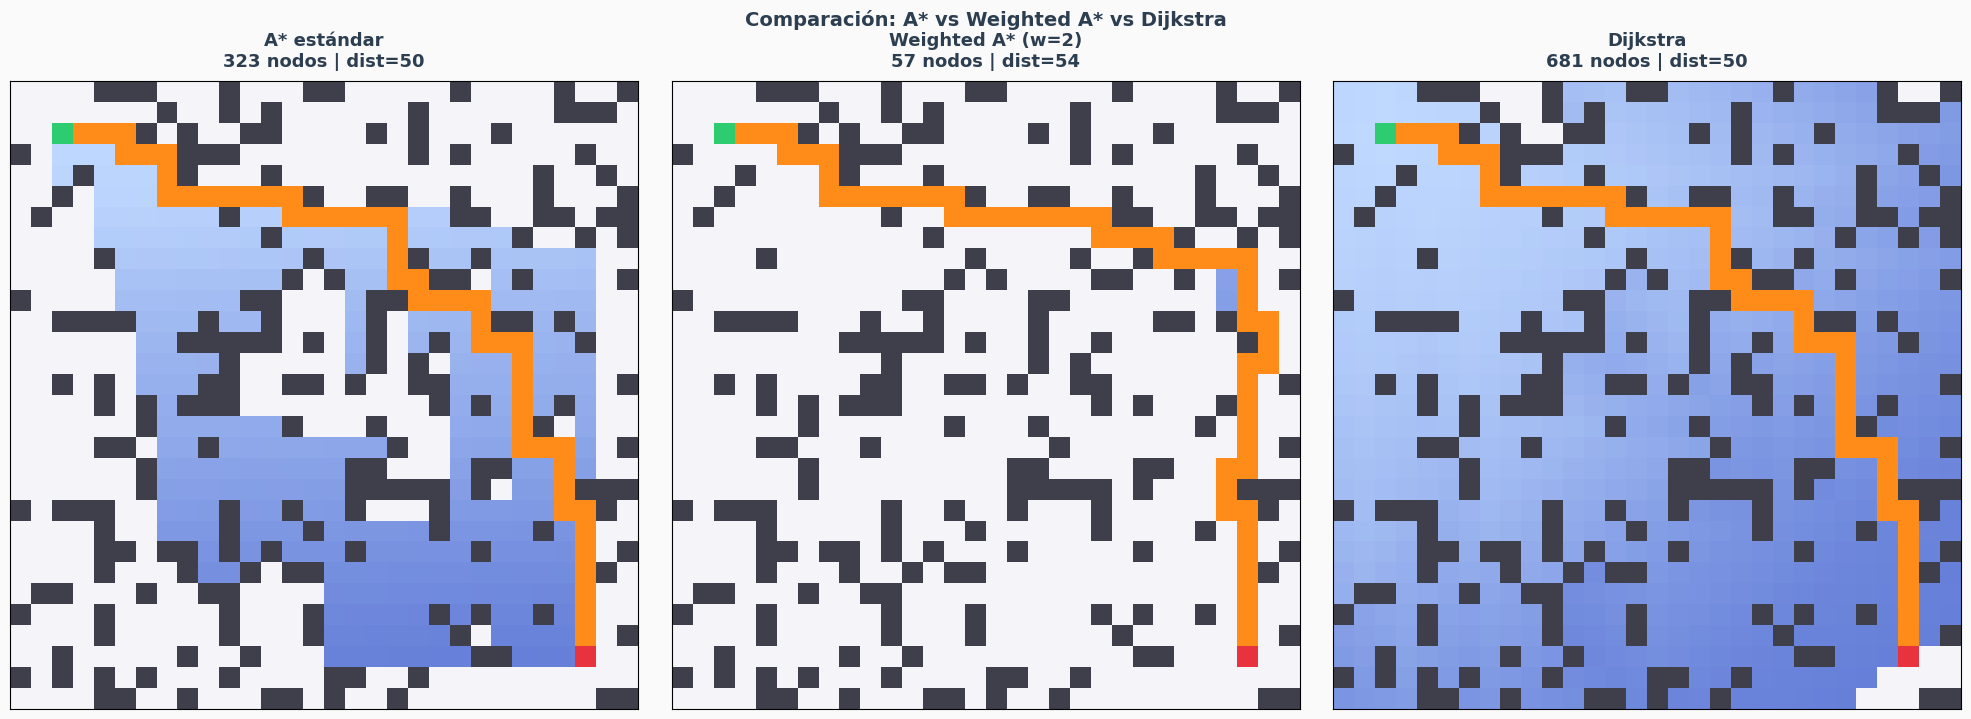


Imagen 6. Comparación triple mostrando cómo weighted A* puede encontrar caminos de distinta longitud.

Distancias: A*=50, Weighted A*=54, Dijkstra=50
→ Weighted A* encontró un camino 4 aristas más largo que el óptimo.


In [20]:
def ejecutarAEstrellaPonderado(mapa, inicio, fin, peso=2.0):
    tiempoInicio = time.perf_counter()
    
    frontera = []
    heapq.heappush(frontera, (0, inicio))
    costoAcumulado = {inicio: 0}
    padres = {inicio: None}
    explorados = set()
    ordenExploracion = []
    pasos = 0
    
    while frontera:
        pasos += 1
        _, actual = heapq.heappop(frontera)
        
        if actual in explorados:
            continue
        
        explorados.add(actual)
        ordenExploracion.append(actual)
        
        if actual == fin:
            break
        
        for vecino in obtenerVecinos(actual, mapa):
            nuevoCosto = costoAcumulado[actual] + 1
            if vecino not in costoAcumulado or nuevoCosto < costoAcumulado[vecino]:
                costoAcumulado[vecino] = nuevoCosto
                prioridad = nuevoCosto + peso * heuristicaManhattan(vecino, fin)
                heapq.heappush(frontera, (prioridad, vecino))
                padres[vecino] = actual
    
    tiempoFin = time.perf_counter()
    
    camino = []
    nodo = fin
    while nodo is not None:
        camino.append(nodo)
        nodo = padres.get(nodo)
    camino.reverse()
    
    nodosFrontera = len([n for _, n in frontera if n not in explorados])
    
    return {
        'nombre': f'Weighted A* (w={peso})',
        'explorados': explorados,
        'ordenExploracion': ordenExploracion,
        'camino': camino,
        'numExplorados': len(explorados),
        'numFrontera': nodosFrontera,
        'pasos': pasos,
        'tiempo': tiempoFin - tiempoInicio,
        'distancia': len(camino) - 1
    }

resWeighted = ejecutarAEstrellaPonderado(mapa, inicio, fin, peso=2.0)

fig, ejes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#fafafa')

dibujarMapaGenerico(ejes[0], mapa, resultadoAEstrella, inicio, fin,
                    f"A* estándar\n{resultadoAEstrella['numExplorados']} nodos | dist={resultadoAEstrella['distancia']}")
dibujarMapaGenerico(ejes[1], mapa, resWeighted, inicio, fin,
                    f"Weighted A* (w=2)\n{resWeighted['numExplorados']} nodos | dist={resWeighted['distancia']}")
dibujarMapaGenerico(ejes[2], mapa, resultadoDijkstra, inicio, fin,
                    f"Dijkstra\n{resultadoDijkstra['numExplorados']} nodos | dist={resultadoDijkstra['distancia']}")

plt.suptitle('Comparación: A* vs Weighted A* vs Dijkstra',
             fontsize=14, fontweight='bold', color='#2c3e50', y=1.02)
plt.tight_layout()
plt.savefig('weighted_comparacion.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f"\nImagen 6. Comparación triple mostrando cómo weighted A* puede encontrar caminos de distinta longitud.")
print(f"\nDistancias: A*={resultadoAEstrella['distancia']}, Weighted A*={resWeighted['distancia']}, Dijkstra={resultadoDijkstra['distancia']}")

if resWeighted['distancia'] > resultadoAEstrella['distancia']:
    print(f"→ Weighted A* encontró un camino {resWeighted['distancia'] - resultadoAEstrella['distancia']} aristas más largo que el óptimo.")
else:
    print("→ En este caso particular, las distancias coinciden. Con otros mapas o pesos mayores la diferencia se nota más.")

## 9. Resumen final

| Aspecto | A* | Dijkstra |
|---------|-----|----------|
| Usa heuristica | Sí | No |
| Camino óptimo | Sí (PERO con heuristica admisible) | Siempre |
| Eficiencia | Mejor en la mayoría de casos | Explora más de lo necesario |
| Sensible al mapa | Mucho (se beneficia de rutas directas) | Poco (siempre expande parejo) |